In [1]:
!pip install timm -q

import os
import timm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 102.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 75.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 29.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 14.2 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

✅ Using device: cuda


In [2]:
import os
import torch
import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


In [3]:
# Adjust these if needed for Kaggle
BASE_DIR = "/kaggle/input/rvf10k/rvf10k"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VALID_DIR = os.path.join(BASE_DIR, "valid")

print("Train path:", TRAIN_DIR)
print("Valid path:", VALID_DIR)


Train path: /kaggle/input/rvf10k/rvf10k/train
Valid path: /kaggle/input/rvf10k/rvf10k/valid


In [4]:
IMAGE_SIZE = 224
BATCH_SIZE = 16

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

valid_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])


In [5]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
valid_dataset = datasets.ImageFolder(VALID_DIR, transform=valid_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Classes:", train_dataset.classes)
print("Train images:", len(train_dataset))
print("Validation images:", len(valid_dataset))


Classes: ['fake', 'real']
Train images: 7000
Validation images: 3000


In [6]:
# Load pretrained ViT
model = timm.create_model("vit_base_patch16_224", pretrained=True)

# Replace head for binary classification
num_features = model.head.in_features
model.head = nn.Linear(num_features, 2)

model = model.to(device)


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=3e-5)


In [8]:
EPOCHS = 10
train_losses, valid_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    valid_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            valid_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_valid_loss = valid_loss / len(valid_loader)
    valid_losses.append(avg_valid_loss)
    accuracy = 100 * correct / total

    print(f"Epoch [{epoch+1}/{EPOCHS}]  Train Loss: {avg_train_loss:.4f}  Valid Loss: {avg_valid_loss:.4f}  Acc: {accuracy:.2f}%")


Epoch [1/10]  Train Loss: 0.3122  Valid Loss: 0.1040  Acc: 96.27%
Epoch [2/10]  Train Loss: 0.1093  Valid Loss: 0.0790  Acc: 96.73%
Epoch [3/10]  Train Loss: 0.0904  Valid Loss: 0.0429  Acc: 98.57%
Epoch [4/10]  Train Loss: 0.0548  Valid Loss: 0.0809  Acc: 97.17%
Epoch [5/10]  Train Loss: 0.0616  Valid Loss: 0.1133  Acc: 95.60%
Epoch [6/10]  Train Loss: 0.0477  Valid Loss: 0.2776  Acc: 91.27%
Epoch [7/10]  Train Loss: 0.0440  Valid Loss: 0.0967  Acc: 96.33%
Epoch [8/10]  Train Loss: 0.0439  Valid Loss: 0.1312  Acc: 95.57%
Epoch [9/10]  Train Loss: 0.0414  Valid Loss: 0.0883  Acc: 96.87%
Epoch [10/10]  Train Loss: 0.0356  Valid Loss: 0.0986  Acc: 96.47%


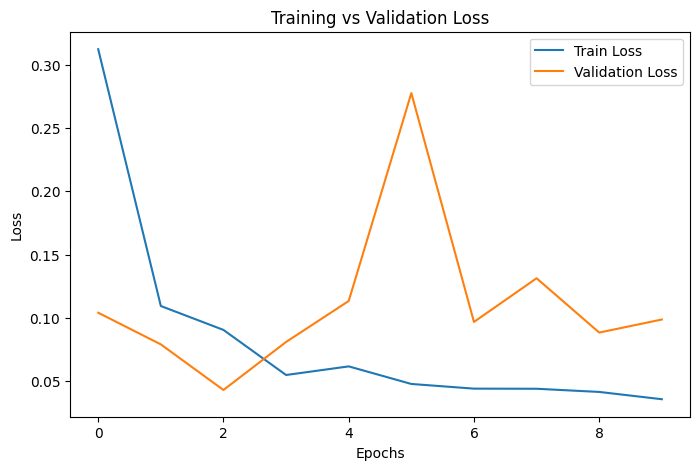

In [9]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


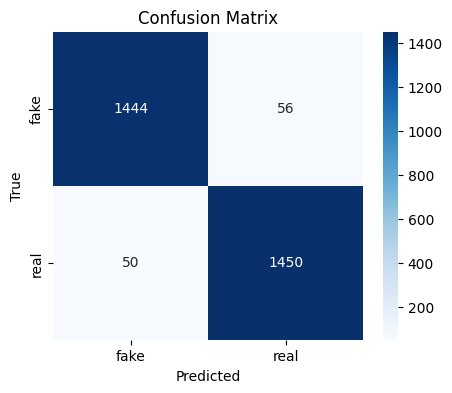


Classification Report:

              precision    recall  f1-score   support

        fake       0.97      0.96      0.96      1500
        real       0.96      0.97      0.96      1500

    accuracy                           0.96      3000
   macro avg       0.96      0.96      0.96      3000
weighted avg       0.96      0.96      0.96      3000



In [10]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in valid_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=train_dataset.classes))


In [11]:
torch.save(model.state_dict(), "deepfake_vit_model.pth")
print("✅ Model saved as deepfake_vit_model.pth")


✅ Model saved as deepfake_vit_model.pth


/tmp/ipykernel_78/1786527852.py:36: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


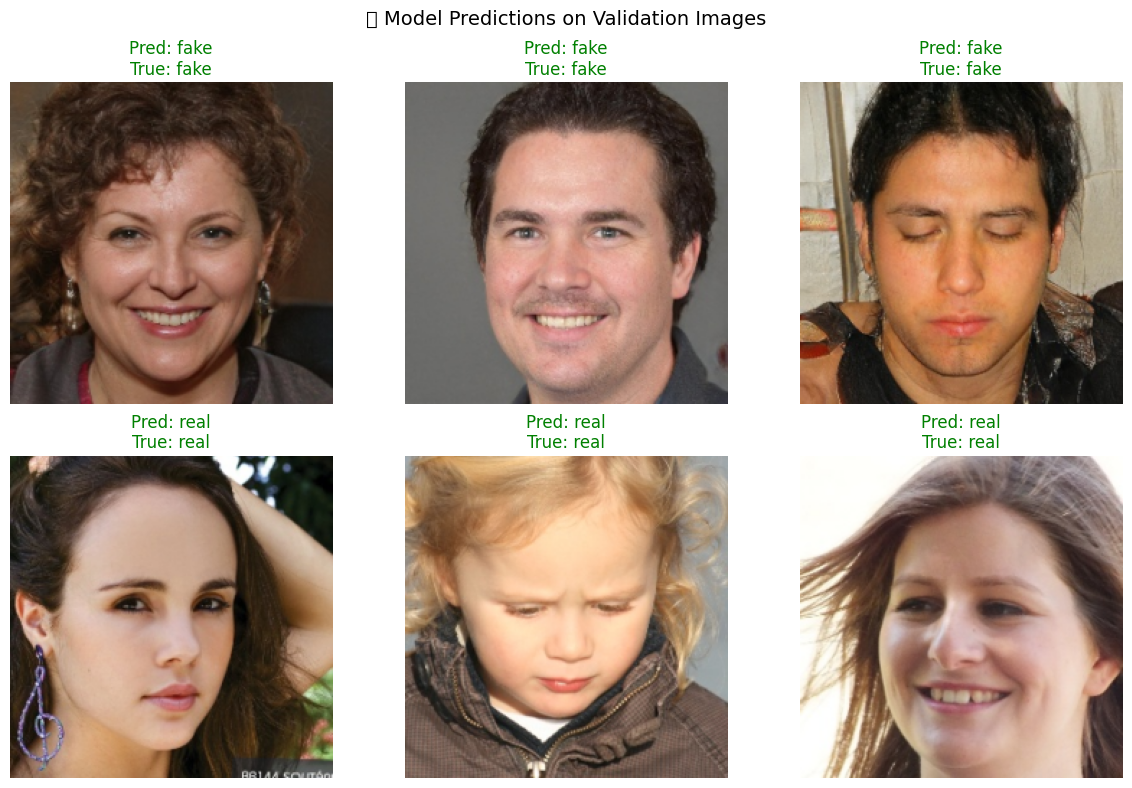

In [12]:
import random
from PIL import Image

# Set model to evaluation mode
model.eval()

# Get a few random samples from validation dataset
num_samples = 6
indices = random.sample(range(len(valid_dataset)), num_samples)

plt.figure(figsize=(12, 8))

for i, idx in enumerate(indices):
    image, label = valid_dataset[idx]
    img_tensor = image.unsqueeze(0).to(device)

    # Prediction
    with torch.no_grad():
        output = model(img_tensor)
        _, pred = torch.max(output, 1)

    pred_label = train_dataset.classes[pred.item()]
    true_label = train_dataset.classes[label]

    # Convert tensor to image for display
    img = image.permute(1, 2, 0).cpu().numpy()
    img = (img * 0.5) + 0.5  # de-normalize

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    color = "green" if pred_label == true_label else "red"
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color)
    plt.axis("off")

plt.suptitle("🔍 Model Predictions on Validation Images", fontsize=14)
plt.tight_layout()
plt.show()


/tmp/ipykernel_78/1632130541.py:39: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  plt.tight_layout()


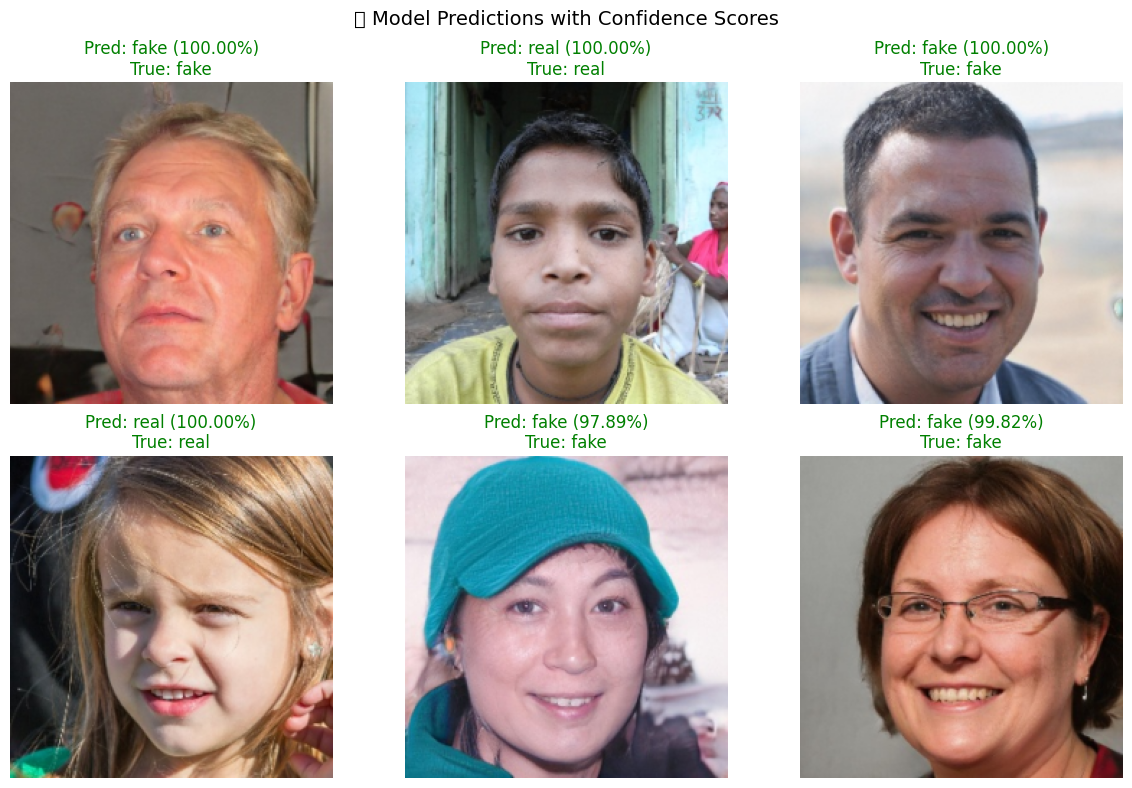

In [13]:
import random
from PIL import Image
import torch.nn.functional as F

# Ensure model is in evaluation mode
model.eval()

# Select random samples from validation dataset
num_samples = 6
indices = random.sample(range(len(valid_dataset)), num_samples)

plt.figure(figsize=(12, 8))

for i, idx in enumerate(indices):
    image, label = valid_dataset[idx]
    img_tensor = image.unsqueeze(0).to(device)

    # Forward pass and prediction
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = F.softmax(outputs, dim=1)
        confidence, pred = torch.max(probs, 1)

    pred_label = train_dataset.classes[pred.item()]
    true_label = train_dataset.classes[label]
    conf_score = confidence.item() * 100  # percentage

    # De-normalize and prepare image for display
    img = image.permute(1, 2, 0).cpu().numpy()
    img = (img * 0.5) + 0.5  # reverse normalization

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    color = "green" if pred_label == true_label else "red"
    plt.title(f"Pred: {pred_label} ({conf_score:.2f}%)\nTrue: {true_label}", color=color)
    plt.axis("off")

plt.suptitle("🔍 Model Predictions with Confidence Scores", fontsize=14)
plt.tight_layout()
plt.show()
